## Problem decyzyjny – inwestycje: mieszkania 2 pokoje

**Kryteria:**

1. Cena mieszkania [zł] – *koszt*
2. Powierzchnia [m²] – *zysk*  
3. Piętro [nr piętra] – *zysk*
4. Powierzchnia balkonu [m²] – *zysk*  
5. Cena parkingu [zł] – *koszt*

**Alternatywy (mieszkania 2‑pokojowe):**

- A1 – Heyki City  
- A2 – Floriana  
- A3 – Sedina  
- A4 – Grand Bvlwar  
- A5 – Gardenia  
- A6 – Silver Garden  

**Macierz decyzyjna:**

| Alt             | Cena [zł] | Powierzchnia [m²] | Piętro | Balkon [m²] | Cena parkingu [zł] |
|-----------------|--------------|----------------------|----------|----------------|------------------------|
| Heyki City       | 540598       | 37.72                | 4        | 8.29           | 65000                  |
| Floriana     | 500760       | 42.80                | 4        | 4.00           | 60000                  |
| Sedina       | 615489       | 38.71                | 5        | 3.55           | 65000                  |
| GrandBvlwar  | 483720       | 34.80                | 2        | 3.98           | 65000                  |
| Gardenia     | 559816       | 44.08                | 1        | 0.00           | 65000                  |
| SilverGarden | 520520       | 40.04                | 7        | 0.00           | 70000                  |

In [97]:
import numpy as np
from pymcdm.methods import TOPSIS, SPOTIS, VIKOR, WASPAS, COMET
from pymcdm.weights.subjective import AHP, RANCOM
from pymcdm.weights import critic_weights, entropy_weights
from pymcdm.helpers import rankdata, rrankdata
from pymcdm.methods.comet_tools import MethodExpert
from pymcdm.correlations import weighted_spearman, rank_similarity_coef, wsc
from pymcdm.visuals import ranking_flows, correlation_heatmap

In [ ]:


D = np.array([
    [540598, 37.72, 4, 8.29, 65000],   # A1 Heyki City
    [500760, 42.80, 4, 4.00, 60000],   # A2 Floriana
    [615489, 38.71, 5, 3.55, 65000],   # A3 Sedina
    [483720, 34.80, 2, 3.98, 65000],   # A4 Grand Bvlwar
    [559816, 44.08, 1, 0.00, 65000],   # A5 Gardenia
    [520520, 40.04, 7, 0.00, 70000],   # A6 Silver Garden
], dtype=float)
types = np.array([-1, 1, 1, 1, -1]) 
bounds = np.array([
    [483720, 615489],  
    [34.80, 44.08],    
    [1, 7],            
    [0.00, 8.29],      
    [60000, 70000]     
], dtype=float)
ranking = [1, 2, 5, 3, 4]
weights_list = []
for method_w in [AHP, RANCOM, critic_weights, entropy_weights]:
    if method_w == AHP:
        weights = method_w(ranking)()
        weights_list.append(weights)
    elif method_w == RANCOM:
        weights = method_w(ranking)()
        rancom_weights = weights
        weights_list.append(weights)
    elif method_w == critic_weights:
        weights = method_w(D)
        weights_list.append(weights)
    elif method_w == entropy_weights:
        weights = method_w(D)
        weights_list.append(weights)

for i in range(len(weights_list)):
    print(f"Wagi metodą {['AHP', 'RANCOM', 'CRITIC', 'ENTROPY'][i]}: {weights_list[i]}")

Wagi metodą AHP: [0.44328562 0.19724056 0.10798204 0.13913235 0.11235943]
Wagi metodą RANCOM: [0.36 0.28 0.04 0.2  0.12]
Wagi metodą CRITIC: [0.17351796 0.23018051 0.17025468 0.25179954 0.17424731]
Wagi metodą ENTROPY: [1.63368171e-03 1.58228417e-03 7.26042921e-02 9.23670846e-01
 5.08895577e-04]


Macierz podobieństw WSC:
 [[1.         0.86506653 0.7593624  0.30017757]
 [0.86506653 1.         0.77315053 0.27397587]
 [0.7593624  0.77315053 1.         0.44251793]
 [0.30017757 0.27397587 0.44251793 1.        ]]


<Axes: >

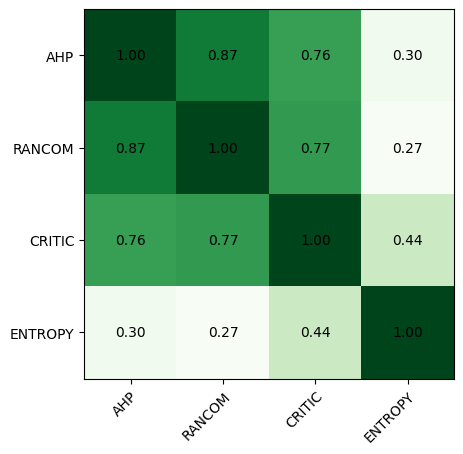

In [101]:
methods = ['AHP', 'RANCOM', 'CRITIC', 'ENTROPY']
n = len(weights_list)
W = np.eye(n)  

for i in range(n):
    for j in range(i + 1, n):
        sim = wsc(weights_list[i], weights_list[j])
        W[i, j] = W[j, i] = sim   

print("Macierz podobieństw WSC:\n", W)

correlation_heatmap(W, labels=methods)


In [82]:
pref_results = []
rankings = []
for method in [TOPSIS, SPOTIS, VIKOR, WASPAS, COMET]:
    if method == TOPSIS:
        body = method()
        pref = body(D, weights_list[1], types)
        r = rrankdata(pref)
    elif method == SPOTIS:
        body = method(bounds)
        pref = body(D, weights_list[1], types)
        r = rankdata(pref)
    elif method == VIKOR:
        body = method()
        pref = body(D, weights_list[1], types)
        r = rankdata(pref)
    elif method == WASPAS:
        body = method()
        pref = body(D, weights_list[1], types)
        r = rrankdata(pref)
    elif method == COMET:
        cvalues = np.vstack((
        np.min(D, axis=0),
        np.max(D, axis=0))).T
        body = COMET(cvalues, MethodExpert(TOPSIS(), weights_list[1], types))
        pref = body(D)   
        r = rrankdata(pref)     

    pref_results.append(pref)
    rankings.append(r)
    print(f"Ranking {method.__name__}: {r}")



Ranking TOPSIS: [3. 1. 6. 2. 4. 5.]
Ranking SPOTIS: [2. 1. 6. 3. 4. 5.]
Ranking VIKOR: [2. 1. 6. 5. 3. 4.]
Ranking WASPAS: [1. 2. 4. 3. 6. 5.]
Ranking COMET: [3. 1. 6. 2. 5. 4.]


[[3. 1. 6. 2. 4. 5.]
 [2. 1. 6. 3. 4. 5.]
 [2. 1. 6. 5. 3. 4.]
 [1. 2. 4. 3. 6. 5.]
 [3. 1. 6. 2. 5. 4.]]


<Axes: ylabel='Position in ranking'>

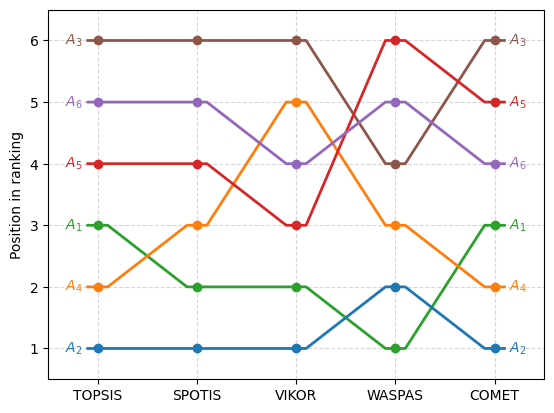

In [87]:
r_flows = np.array(rankings)
print(r_flows)
ranking_flows(rankings, ['TOPSIS', 'SPOTIS', 'VIKOR', 'WASPAS', 'COMET'])


In [ ]:
for i in range(len(rankings)):
    for j in range(i + 1, len(rankings)):
        spearman_corr = weighted_spearman(rankings[i], rankings[j])
        ws = rank_similarity_coef(rankings[i], rankings[j])

        print(f"Porównanie {['TOPSIS', 'SPOTIS', 'VIKOR', 'WASPAS', 'COMET'][i]} vs {['TOPSIS', 'SPOTIS', 'VIKOR', 'WASPAS', 'COMET'][j]}:")
        print(f"  Skorelowanie Spearmana: {spearman_corr:.4f}")
        print(f"  Współczynnik podobieństwa rang: {ws:.4f}\n")


Porównanie TOPSIS vs SPOTIS:
  Skorelowanie Spearmana: 0.9265
  Współczynnik podobieństwa rang: 0.8958

Porównanie TOPSIS vs VIKOR:
  Skorelowanie Spearmana: 0.6571
  Współczynnik podobieństwa rang: 0.7422

Porównanie TOPSIS vs WASPAS:
  Skorelowanie Spearmana: 0.6245
  Współczynnik podobieństwa rang: 0.7063

Porównanie TOPSIS vs COMET:
  Skorelowanie Spearmana: 0.9592
  Współczynnik podobieństwa rang: 0.9714

Porównanie SPOTIS vs VIKOR:
  Skorelowanie Spearmana: 0.8531
  Współczynnik podobieństwa rang: 0.8880

Porównanie SPOTIS vs WASPAS:
  Skorelowanie Spearmana: 0.7796
  Współczynnik podobieństwa rang: 0.7896

Porównanie SPOTIS vs COMET:
  Skorelowanie Spearmana: 0.8857
  Współczynnik podobieństwa rang: 0.8672

Porównanie VIKOR vs WASPAS:
  Skorelowanie Spearmana: 0.5429
  Współczynnik podobieństwa rang: 0.6698

Porównanie VIKOR vs COMET:
  Skorelowanie Spearmana: 0.6082
  Współczynnik podobieństwa rang: 0.8307

Porównanie WASPAS vs COMET:
  Skorelowanie Spearmana: 0.6571
  Współczy